<a href="https://colab.research.google.com/github/njwbilll/Tugas-2_scikit-learn-Cookbook-O-Reilly-_Najwa-Bilqis-Al-Khalidah/blob/main/05_Linear_Models_and_Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 5: Linear Models and Regularization

**Referensi:** scikit-learn Cookbook, Third Edition - John Sukup (Packt Publishing, 2025)

---

## Ringkasan Chapter

Chapter 5 membahas model-model linear dan teknik regularisasi dalam Machine Learning. Linear regression adalah salah satu model ML paling fundamental, yang berusaha menemukan hubungan matematis antara data yang dapat direpresentasikan sebagai persamaan garis. Chapter ini juga memperkenalkan Ridge, Lasso, dan ElasticNet sebagai teknik regularisasi untuk mencegah overfitting, serta polynomial regression dan spline interpolation untuk memodelkan hubungan non-linear.

### Topik yang Dibahas:
1. Pengantar linear models (Linear Regression)
2. Ridge dan Lasso regression (L2 dan L1 regularization)
3. ElasticNet dan regularization
4. Teori regularisasi: bias-variance trade-off
5. Polynomial regression dan Spline interpolation
6. Latihan praktis dengan teknik regularisasi


---
## Setup: Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(123)
print("Library berhasil diimport.")


Library berhasil diimport.


---
## 1. Pengantar Linear Models

### Penjelasan Teori

**Linear regression** adalah model prediktif yang paling mendasar, yang berusaha menemukan hubungan linear antara variabel independen (fitur) dan variabel dependen (target). Persamaan matematisnya:

```
y = beta_0 + beta_1*x_1 + beta_2*x_2 + ... + beta_n*x_n + epsilon
```

di mana:
- `y` adalah nilai yang diprediksi
- `beta_0` adalah intercept (bias)
- `beta_n` adalah koefisien untuk setiap fitur
- `x_n` adalah nilai fitur
- `epsilon` adalah error term

**Ordinary Least Squares (OLS)** adalah metode paling umum untuk fitting linear regression, yaitu meminimalkan jumlah kuadrat selisih antara nilai aktual dan nilai prediksi (residuals).

**Metrik evaluasi untuk regresi:**
- **MSE (Mean Squared Error):** Rata-rata kuadrat error. Sensitif terhadap outlier.
- **RMSE (Root MSE):** Akar MSE. Lebih mudah diinterpretasikan karena satuan sama dengan target.
- **R-squared (R2):** Proporsi varians target yang dijelaskan oleh model. R2 = 1 sempurna, R2 = 0 setara model naive.

> **Catatan:** R2 bisa menyesatkan karena nilainya selalu meningkat saat lebih banyak variabel ditambahkan, meski tidak informatif. Adjusted R2 lebih disarankan untuk membandingkan model dengan jumlah fitur berbeda.


In [2]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Buat dataset regresi sintetis dengan multikolinearitas dan banyak fitur
X, y = make_regression(
    n_samples=1000, n_features=100,
    n_informative=10, noise=20, random_state=123
)

# Tambahkan multikolinearitas: buat setengah fitur berkorelasi
for i in range(50, 100):
    X[:, i] = X[:, i-50] + np.random.normal(0, 0.1, size=1000)

feature_names = [f'feature_{i}' for i in range(100)]

# Scale target dan tambahkan non-linearitas ringan
X_plot = X[:, 0].reshape(-1, 1)
y = y * 1000
y = (y + np.sin(X_plot.ravel()) * 150
       + np.exp(X_plot.ravel() / 10))

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print(f"Shape dataset: {df.shape}")
print(f"5 fitur pertama dan statistik target:")
display(df[feature_names[:5] + ['target']].describe().round(2))


Shape dataset: (1000, 101)
5 fitur pertama dan statistik target:


,feature_0,feature_1,feature_2,feature_3,feature_4,target
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,-0.01,0.04,0.04,-0.00,-0.02,1229.17
std,1.02,1.00,1.00,1.00,0.97,223932.64
min,-3.77,-2.80,-3.11,-2.63,-2.99,-898454.59
25%,-0.68,-0.66,-0.67,-0.69,-0.68,-152797.32
50%,0.03,0.05,0.05,0.02,-0.02,-5195.60
75%,0.67,0.67,0.77,0.68,0.60,150213.72
max,2.82,3.97,2.87,3.14,3.06,683148.06


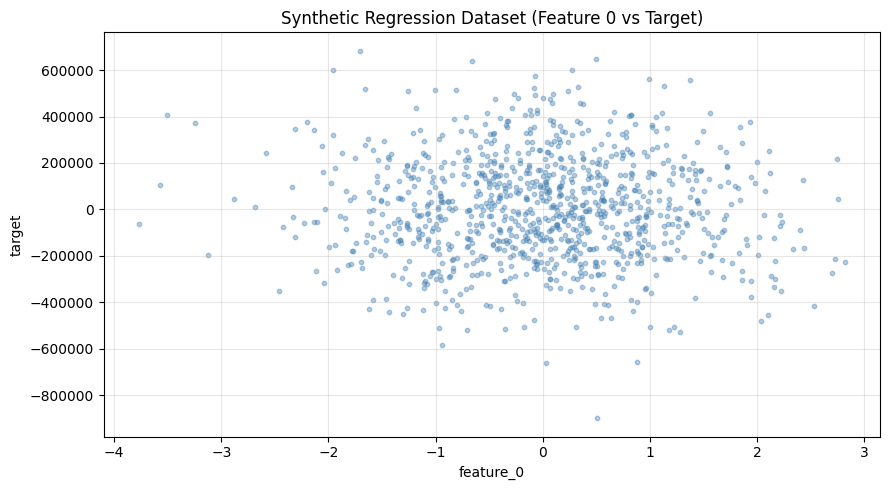

In [3]:
# Visualisasi dataset (menggunakan feature_0 untuk 2D)
plt.figure(figsize=(9, 5))
plt.scatter(X_plot, y, alpha=0.4, color='steelblue', s=10)
plt.xlabel('feature_0')
plt.ylabel('target')
plt.title('Synthetic Regression Dataset (Feature 0 vs Target)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [4]:
# Split data sebelum transformasi apapun
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123
)

# Buat dan latih Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Prediksi dan evaluasi
y_pred_linear = linear_model.predict(X_test)
mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear  = r2_score(y_test, y_pred_linear)

print("Linear Regression:")
print(f"  MSE:  {mse_linear:,.2f}")
print(f"  RMSE: {np.sqrt(mse_linear):,.2f}")
print(f"  R2:   {r2_linear:.4f}")


Linear Regression:
  MSE:  46,550,591,070.53
  RMSE: 215,755.86
  R2:   0.0648


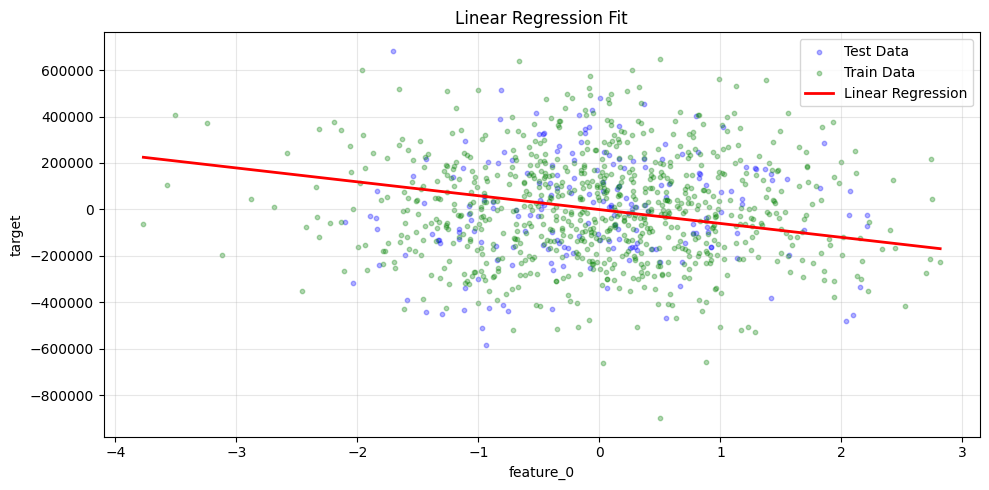

In [5]:
# Visualisasi regression line vs data (menggunakan feature_0 saja)
X_line = np.linspace(df['feature_0'].min(), df['feature_0'].max(), 100).reshape(-1, 1)
X_line_full = np.zeros((100, len(feature_names)))
X_line_full[:, 0] = X_line.ravel()
y_line_linear = linear_model.predict(pd.DataFrame(X_line_full, columns=feature_names))

plt.figure(figsize=(10, 5))
plt.scatter(X_test[:, 0], y_test, color='blue', alpha=0.3, s=10, label='Test Data')
plt.scatter(X_train[:, 0], y_train, color='green', alpha=0.3, s=10, label='Train Data')
plt.plot(X_line, y_line_linear, color='red', linewidth=2, label='Linear Regression')
plt.xlabel('feature_0')
plt.ylabel('target')
plt.title('Linear Regression Fit')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## 2. Ridge dan Lasso Regression

### Penjelasan Teori

Ridge dan Lasso adalah dua teknik regularisasi yang memperkuat performa linear regression dengan menambahkan penalty term ke fungsi loss. Regularisasi mencegah overfitting dengan mencegah model menjadi terlalu kompleks.

**Ridge Regression (L2 Regularization):**

Menambahkan penalty L2 ke fungsi loss OLS:
```
Loss = sum((y_i - y_hat_i)^2) + alpha * sum(beta_j^2)
```
- Penalty mendorong koefisien kecil, tapi tidak pernah menjadi tepat 0.
- Berguna ketika ingin mempertahankan semua fitur tapi mengurangi dampaknya.
- Parameter `alpha`: semakin besar, semakin kuat regularisasi.

**Lasso Regression (L1 Regularization):**

Menambahkan penalty L1 ke fungsi loss OLS:
```
Loss = sum((y_i - y_hat_i)^2) + alpha * sum(|beta_j|)
```
- Penalty L1 dapat membuat koefisien menjadi **tepat 0**, secara otomatis melakukan feature selection.
- Berguna ketika menduga banyak fitur tidak relevan.

**Kapan menggunakan masing-masing:**
- Ridge: Ketika semua fitur mungkin berkontribusi, tapi ingin mengurangi dampak fitur yang berkorelasi.
- Lasso: Ketika menduga banyak fitur redundan dan ingin model sparse (banyak koefisien nol).


In [6]:
from sklearn.linear_model import Ridge, Lasso

# Ridge Regression
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

# Lasso Regression
lasso_model = Lasso(alpha=10.0, max_iter=10000, tol=0.001)
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)

# Kumpulkan metrik semua model
metrics = {
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
    'MSE': [
        mean_squared_error(y_test, y_pred_linear),
        mean_squared_error(y_test, y_pred_ridge),
        mean_squared_error(y_test, y_pred_lasso),
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_linear)),
        np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test, y_pred_lasso)),
    ],
    'R2': [
        r2_score(y_test, y_pred_linear),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso),
    ]
}

metrics_df = pd.DataFrame(metrics).sort_values('MSE').reset_index(drop=True)
print("Perbandingan performa model:")
display(metrics_df.round(4))


Perbandingan performa model:


,Model,MSE,RMSE,R2
0,Ridge Regression,4.534109e+10,212934.4777,0.0891
1,Lasso Regression,4.637711e+10,215353.4560,0.0683
2,Linear Regression,4.655059e+10,215755.8599,0.0648


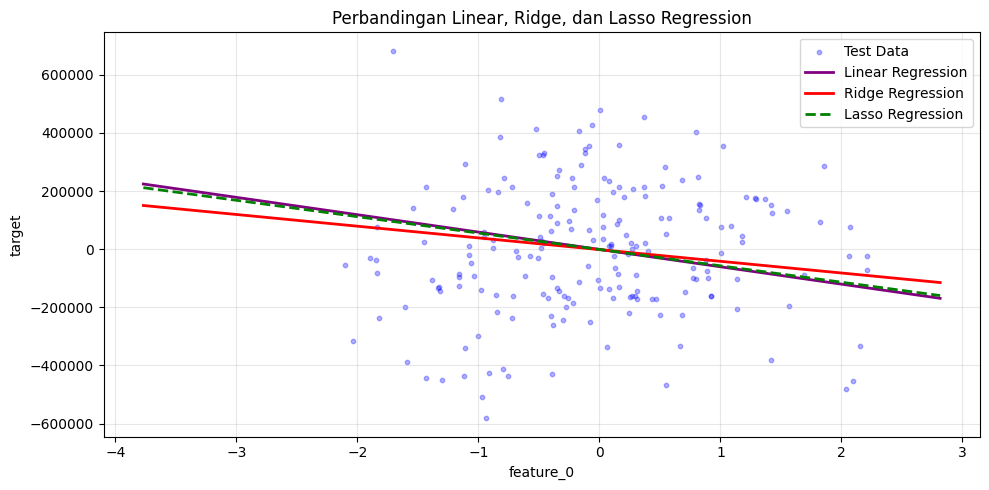

In [7]:
# Visualisasi perbandingan regression lines
y_line_ridge = ridge_model.predict(pd.DataFrame(X_line_full, columns=feature_names))
y_line_lasso = lasso_model.predict(pd.DataFrame(X_line_full, columns=feature_names))

plt.figure(figsize=(10, 5))
plt.scatter(X_test[:, 0], y_test, color='blue', alpha=0.3, s=10, label='Test Data')
plt.plot(X_line, y_line_linear, color='purple', linewidth=2, label='Linear Regression')
plt.plot(X_line, y_line_ridge, color='red', linewidth=2, label='Ridge Regression')
plt.plot(X_line, y_line_lasso, color='green', linewidth=2, linestyle='--', label='Lasso Regression')
plt.xlabel('feature_0')
plt.ylabel('target')
plt.title('Perbandingan Linear, Ridge, dan Lasso Regression')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [8]:
# Efek Lasso pada feature selection: lihat berapa koefisien yang menjadi nol
n_zero_lasso  = np.sum(lasso_model.coef_ == 0)
n_nonzero_lasso = np.sum(lasso_model.coef_ != 0)
n_zero_ridge  = np.sum(np.abs(ridge_model.coef_) < 1e-6)

print(f"Total fitur: {len(feature_names)}")
print()
print(f"Lasso (alpha=10.0):")
print(f"  Koefisien = 0 (dieliminasi): {n_zero_lasso}")
print(f"  Koefisien != 0 (dipertahankan): {n_nonzero_lasso}")
print()
print(f"Ridge (alpha=1.0):")
print(f"  Koefisien ~ 0 (< 1e-6): {n_zero_ridge}")
print(f"  Semua koefisien dipertahankan (shrunk, tidak dieliminasi).")


Total fitur: 100

Lasso (alpha=10.0):
  Koefisien = 0 (dieliminasi): 0
  Koefisien != 0 (dipertahankan): 100

Ridge (alpha=1.0):
  Koefisien ~ 0 (< 1e-6): 0
  Semua koefisien dipertahankan (shrunk, tidak dieliminasi).


---
## 3. ElasticNet dan Regularization

### Penjelasan Teori

**ElasticNet** adalah hybrid dari Ridge dan Lasso yang menggabungkan kekuatan keduanya untuk menangani berbagai jenis data. ElasticNet menggabungkan penalty L1 (Lasso) dan L2 (Ridge) dalam fungsi loss-nya:

```
Loss = sum((y_i - y_hat_i)^2) + alpha * (lambda1 * sum(|beta_j|) + lambda2 * sum(beta_j^2))
```

**Parameter utama ElasticNet:**
- `alpha`: Mengontrol kekuatan regularisasi secara keseluruhan.
- `l1_ratio`: Mengontrol proporsi L1 vs L2:
  - `l1_ratio = 1`: Berperilaku seperti Lasso (hanya L1).
  - `l1_ratio = 0`: Berperilaku seperti Ridge (hanya L2).
  - `0 < l1_ratio < 1`: Kombinasi keduanya.

**Kapan menggunakan ElasticNet:**
- Ketika dataset memiliki banyak fitur yang saling berkorelasi (multikolinearitas tinggi).
- Ketika ingin keuntungan feature selection dari Lasso, tapi juga stabilitas dari Ridge.
- Ketika jumlah fitur lebih banyak dari jumlah sampel.

**Coefficient path plot:** Visualisasi yang menunjukkan bagaimana koefisien model berubah seiring perubahan kekuatan regularisasi (alpha). Fitur yang koefisiennya cepat mencapai 0 adalah fitur yang paling tidak penting.


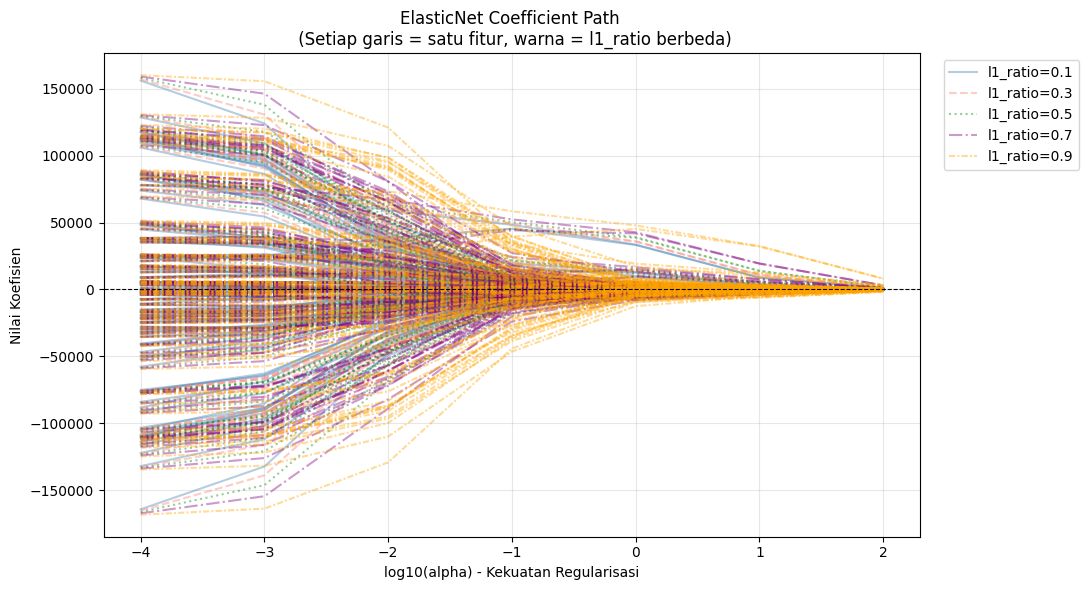

Saat alpha meningkat (kanan), koefisien menyusut menuju 0.
l1_ratio mendekati 1 (warna oranye): lebih seperti Lasso, koefisien lebih cepat menjadi 0.


In [15]:
from sklearn.linear_model import ElasticNet

# Buat range alpha dan l1_ratio untuk pengujian
alphas    = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]

# Plot coefficient path
plt.figure(figsize=(11, 6))
line_styles = ['solid', 'dashed', 'dotted', 'dashdot', (0, (3, 1, 1, 1))]
colors_en   = ['steelblue', 'salmon', 'green', 'purple', 'orange']

for l1_ratio, ls, col in zip(l1_ratios, line_styles, colors_en):
    coefs = []
    for alpha in alphas:
        en = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=123, max_iter=10000, tol=1e-4)
        en.fit(X_train, y_train)
        coefs.append(en.coef_)
    coefs = np.array(coefs)

    for feature_idx in range(X_train.shape[1]):
        plt.plot(
            np.log10(alphas), coefs[:, feature_idx],
            label=f'l1_ratio={l1_ratio}' if feature_idx == 0 else "",
            alpha=0.4, linestyle=ls, color=col
        )

plt.xlabel('log10(alpha) - Kekuatan Regularisasi')
plt.ylabel('Nilai Koefisien')
plt.title('ElasticNet Coefficient Path \n (Setiap garis = satu fitur, warna = l1_ratio berbeda)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Saat alpha meningkat (kanan), koefisien menyusut menuju 0.")
print("l1_ratio mendekati 1 (warna oranye): lebih seperti Lasso, koefisien lebih cepat menjadi 0.")


In [17]:
# Fit ElasticNet dengan parameter terbaik dan evaluasi
elastic_model = ElasticNet(
    alpha=1.0, l1_ratio=0.5, random_state=123,
    max_iter=10000, tol=1e-4
)
elastic_model.fit(X_train, y_train)
y_pred_elastic = elastic_model.predict(X_test)

mse_elastic  = mean_squared_error(y_test, y_pred_elastic)
r2_elastic   = r2_score(y_test, y_pred_elastic)
n_zero_en    = np.sum(elastic_model.coef_ == 0)

# Tambahkan ElasticNet ke tabel perbandingan
new_row = pd.DataFrame({
    'Model': ['ElasticNet Regression'],
    'MSE':   [mse_elastic],
    'RMSE':  [np.sqrt(mse_elastic)],
    'R2':    [r2_elastic]
})
full_metrics = pd.concat([metrics_df, new_row], ignore_index=True).sort_values('MSE').reset_index(drop=True)

print("Perbandingan semua model (termasuk ElasticNet):")
display(full_metrics.round(4))
print(f"ElasticNet: koefisien = 0 (dieliminasi): {n_zero_en} dari {len(feature_names)}")


Perbandingan semua model (termasuk ElasticNet):


,Model,MSE,RMSE,R2
0,ElasticNet Regression,4.261664e+10,206437.9698,0.1438
1,Ridge Regression,4.534109e+10,212934.4777,0.0891
2,Lasso Regression,4.637711e+10,215353.4560,0.0683
3,Linear Regression,4.655059e+10,215755.8599,0.0648


ElasticNet: koefisien = 0 (dieliminasi): 0 dari 100


---
## 4. Teori Regularisasi: Bias-Variance Trade-off

### Penjelasan Teori

**Bias-Variance Trade-off** adalah salah satu konsep paling mendasar dalam ML, yang menjelaskan trade-off antara dua sumber error dalam model:

- **Bias (Underfitting):** Error yang berasal dari asumsi yang terlalu sederhana dalam algoritma learning. Model dengan bias tinggi cenderung meleset dari hubungan yang relevan antara fitur dan target.

- **Variance (Overfitting):** Error yang berasal dari sensitivitas berlebihan terhadap fluktuasi kecil dalam training set. Model dengan variance tinggi mempelajari noise dari data training, bukan pola yang mendasarinya.

**Peran regularisasi dalam bias-variance trade-off:**
- Tanpa regularisasi: Model bisa mencapai performa hampir sempurna pada data training, tapi gagal pada data baru (high variance/overfitting).
- Dengan regularisasi: Menambahkan sedikit bias, tapi secara signifikan mengurangi variance, sehingga meningkatkan kemampuan generalisasi model.
- Alpha terlalu besar: Model menjadi terlalu sederhana (high bias/underfitting).
- Alpha optimal: Keseimbangan terbaik antara bias dan variance.

**Bagaimana memilih alpha optimal:**
Gunakan `RidgeCV()`, `LassoCV()`, atau `ElasticNetCV()` yang secara otomatis memilih alpha terbaik melalui cross-validation.


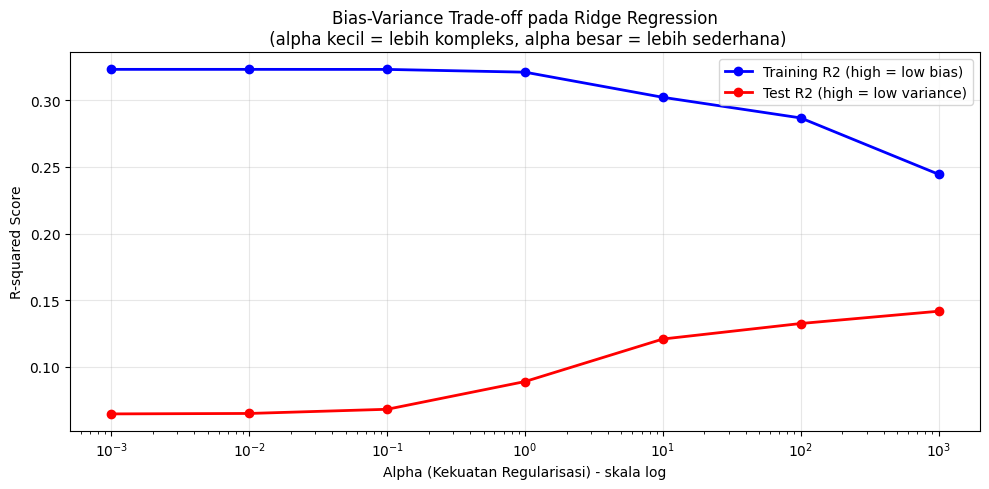

In [19]:
from sklearn.linear_model import RidgeCV

# Demonstrasi dampak nilai alpha pada bias-variance
alphas_test = [0.001, 0.01, 0.1, 1.0, 10, 100, 1000]
train_scores, test_scores = [], []

for alpha in alphas_test:
    ridge_temp = Ridge(alpha=alpha)
    ridge_temp.fit(X_train, y_train)
    train_scores.append(r2_score(y_train, ridge_temp.predict(X_train)))
    test_scores.append(r2_score(y_test, ridge_temp.predict(X_test)))

# Plot bias-variance trade-off
plt.figure(figsize=(10, 5))
plt.semilogx(alphas_test, train_scores, 'b-o', linewidth=2, label='Training R2 (high = low bias)')
plt.semilogx(alphas_test, test_scores,  'r-o', linewidth=2, label='Test R2 (high = low variance)')
plt.xlabel('Alpha (Kekuatan Regularisasi) - skala log')
plt.ylabel('R-squared Score')
plt.title('Bias-Variance Trade-off pada Ridge Regression\n (alpha kecil = lebih kompleks, alpha besar = lebih sederhana)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [20]:
# RidgeCV: memilih alpha optimal secara otomatis via cross-validation
ridge_cv = RidgeCV(alphas=np.logspace(-3, 4, 50), cv=5)
ridge_cv.fit(X_train, y_train)

print(f"Alpha optimal yang ditemukan RidgeCV: {ridge_cv.alpha_:.4f}")
print(f"R2 pada test set dengan alpha optimal: {r2_score(y_test, ridge_cv.predict(X_test)):.4f}")


Alpha optimal yang ditemukan RidgeCV: 372.7594
R2 pada test set dengan alpha optimal: 0.1433


---
## 5. Polynomial Regression dan Spline Interpolation

### Penjelasan Teori

**Polynomial regression** memperluas linear regression dengan memfit persamaan polinomial ke data. Dengan mentransformasi fitur input menjadi term polinomial (x^2, x^3, ...), polynomial regression dapat menangkap hubungan non-linear antara variabel dependen dan independen.

Persamaan polynomial regression derajat n:
```
y = beta_0 + beta_1*x + beta_2*x^2 + ... + beta_n*x^n + epsilon
```

Dalam scikit-learn, ini diimplementasikan dengan `PolynomialFeatures()` (transformer) yang menghasilkan fitur polinomial, lalu dimasukkan ke `LinearRegression()`.

**Bahaya polynomial regression dengan degree tinggi:**
- Degree terlalu tinggi dapat menyebabkan **overfitting** yang parah: model mempelajari noise dalam data training dan gagal generalisasi.
- Oleh karena itu, selalu evaluasi pada test set, bukan hanya training set.

**Spline Interpolation:**
Teknik yang membuat kurva halus melewati sekumpulan titik data dengan membagi data ke segmen-segmen kecil dan memfit polinomial ke masing-masing segmen. Lebih fleksibel dan stabil dibanding polynomial regression degree tinggi.

`SplineTransformer()` di scikit-learn memungkinkan spesifikasi jumlah `n_knots` (titik sambung antar segmen) dan `degree` (derajat polinomial di tiap segmen).


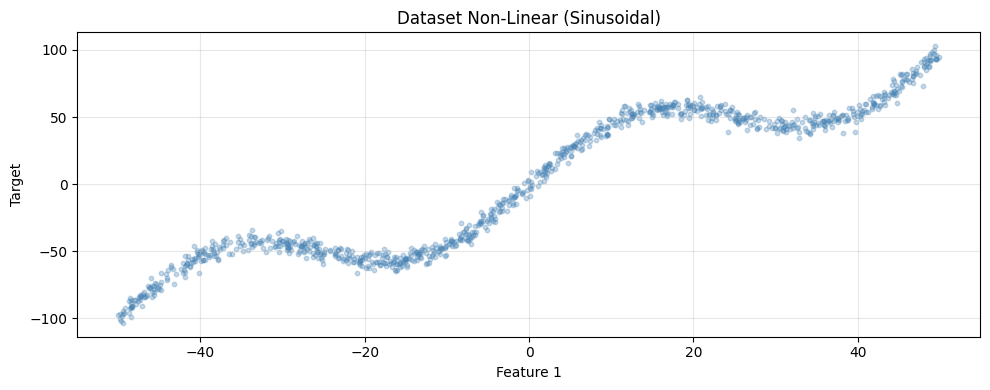

In [21]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Buat dataset baru dengan hubungan non-linear (gelombang sinus)
np.random.seed(123)
n_samples = 1000
X_nl = np.random.uniform(-50, 50, (n_samples, 1))
y_nl = (2 * X_nl[:, 0]
        + 27 * np.sin(X_nl[:, 0] / 8)
        + np.random.normal(0, 4, n_samples))

data_nl = pd.DataFrame({'feature1': X_nl[:, 0], 'target': y_nl})

plt.figure(figsize=(10, 4))
plt.scatter(data_nl['feature1'], data_nl['target'],
            alpha=0.3, s=10, color='steelblue')
plt.title('Dataset Non-Linear (Sinusoidal)')
plt.xlabel('Feature 1')
plt.ylabel('Target')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

X_nl_2d = data_nl[['feature1']]
y_nl_1d  = data_nl['target']


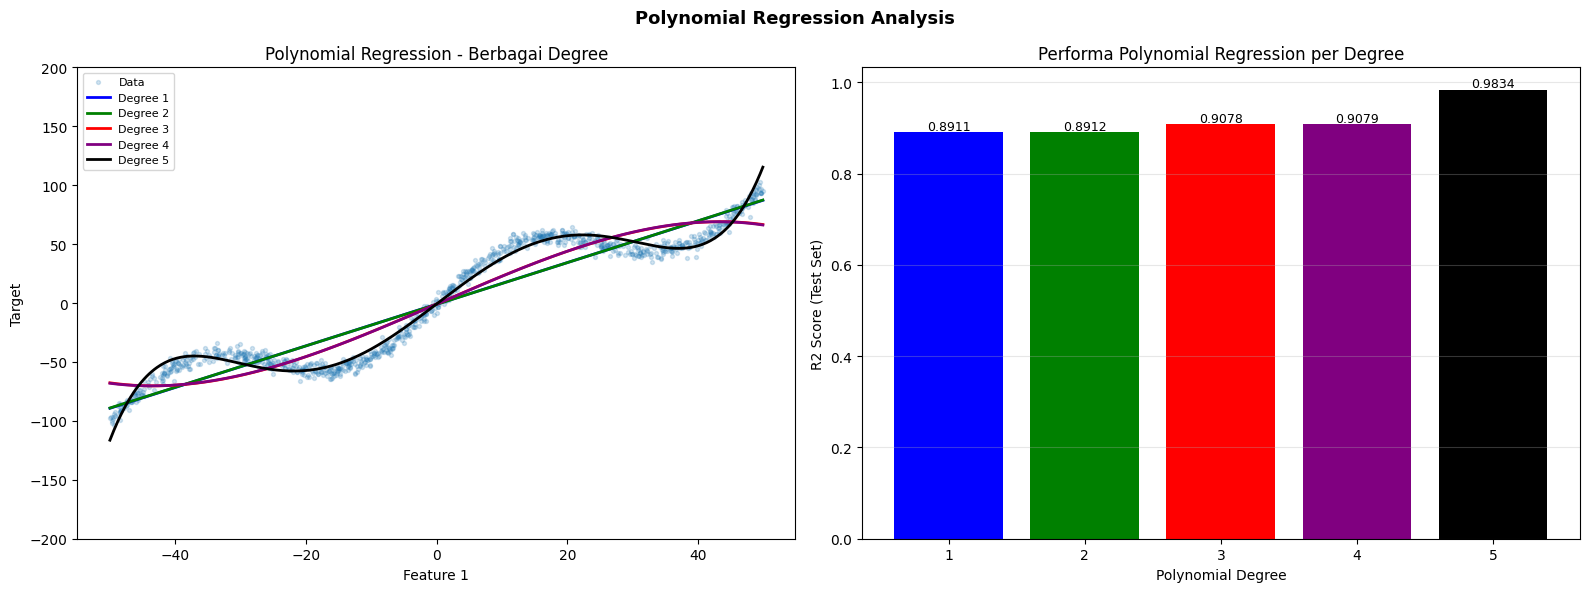

Tabel performa polynomial regression:


,Degree,MSE,R2
0,1,317.01,0.8911
1,2,316.82,0.8912
2,3,268.48,0.9078
3,4,268.23,0.9079
4,5,48.32,0.9834


In [22]:
# Coba berbagai degree polynomial regression
degrees = [1, 2, 3, 4, 5]
results_poly = []
colors_poly  = ['blue', 'green', 'red', 'purple', 'black']

X_plot_nl = np.linspace(X_nl.min(), X_nl.max(), 500).reshape(-1, 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
ax1.scatter(data_nl['feature1'], data_nl['target'], alpha=0.2, s=8, label='Data')

for degree, color in zip(degrees, colors_poly):
    poly   = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X_nl_2d)
    X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
        X_poly, y_nl_1d, test_size=0.2, random_state=123
    )
    model_poly = LinearRegression()
    model_poly.fit(X_train_p, y_train_p)
    y_pred_p = model_poly.predict(X_test_p)

    mse_p = mean_squared_error(y_test_p, y_pred_p)
    r2_p  = r2_score(y_test_p, y_pred_p)
    results_poly.append({'Degree': degree, 'MSE': round(mse_p, 2), 'R2': round(r2_p, 4)})

    # Plot garis prediksi
    X_plot_poly = poly.fit_transform(X_plot_nl)
    y_plot = model_poly.predict(X_plot_poly)
    ax1.plot(X_plot_nl, y_plot, color=color, linewidth=2, label=f'Degree {degree}')

ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Target')
ax1.set_title('Polynomial Regression - Berbagai Degree')
ax1.legend(loc='upper left', fontsize=8)
ax1.set_ylim(-200, 200)

# Plot metrik performa
results_df_poly = pd.DataFrame(results_poly)
ax2.bar(results_df_poly['Degree'].astype(str), results_df_poly['R2'], color=colors_poly)
ax2.set_xlabel('Polynomial Degree')
ax2.set_ylabel('R2 Score (Test Set)')
ax2.set_title('Performa Polynomial Regression per Degree')
for i, (deg, r2_v) in enumerate(zip(results_df_poly['Degree'], results_df_poly['R2'])):
    ax2.text(i, r2_v + 0.005, f'{r2_v:.4f}', ha='center', fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle('Polynomial Regression Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Tabel performa polynomial regression:")
display(results_df_poly)


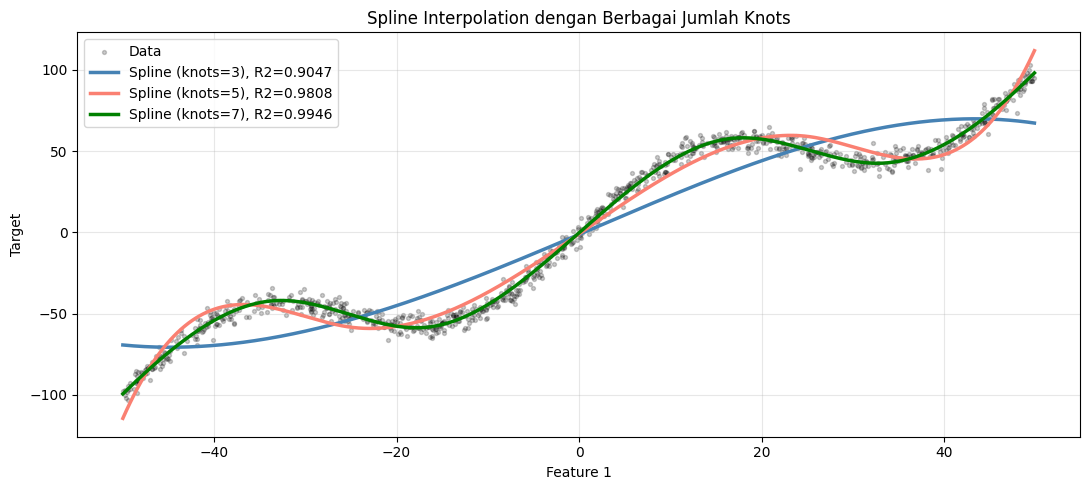

Perbandingan performa Spline Interpolation:


,Number of Knots,MSE,R2
0,3,274.2670,0.9047
1,5,55.3478,0.9808
2,7,15.5021,0.9946


Semakin banyak knots -> MSE semakin kecil, fit semakin baik.


In [23]:
from sklearn.preprocessing import SplineTransformer

# Spline Interpolation dengan berbagai jumlah knots
n_knots_list = [3, 5, 7]
colors_spline = ['steelblue', 'salmon', 'green']
mse_splines, r2_splines = [], []

plt.figure(figsize=(11, 5))
plt.scatter(X_nl, y_nl, color='black', alpha=0.2, s=8, label='Data')

for n_knot, color in zip(n_knots_list, colors_spline):
    spline_pipe = make_pipeline(
        SplineTransformer(n_knots=n_knot, degree=3),
        LinearRegression()
    )
    spline_pipe.fit(X_nl_2d, y_nl_1d)

    y_plot_spline = spline_pipe.predict(X_plot_nl)
    y_pred_spline = spline_pipe.predict(X_nl_2d)

    mse_s = mean_squared_error(y_nl_1d, y_pred_spline)
    r2_s  = r2_score(y_nl_1d, y_pred_spline)
    mse_splines.append(round(mse_s, 4))
    r2_splines.append(round(r2_s, 4))

    plt.plot(X_plot_nl, y_plot_spline, color=color, linewidth=2.5,
             label=f'Spline (knots={n_knot}), R2={r2_s:.4f}')

plt.xlabel('Feature 1')
plt.ylabel('Target')
plt.title('Spline Interpolation dengan Berbagai Jumlah Knots')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

spline_metrics = pd.DataFrame({
    'Number of Knots': n_knots_list,
    'MSE': mse_splines,
    'R2':  r2_splines
})
print("Perbandingan performa Spline Interpolation:")
display(spline_metrics)
print("Semakin banyak knots -> MSE semakin kecil, fit semakin baik.")


---
## 6. Latihan Praktis: Ridge, Lasso, dan ElasticNet pada Dataset Nyata

### Deskripsi

Pada bagian ini kita akan mengaplikasikan ketiga teknik regularisasi pada California Housing dataset yang sesungguhnya (bukan sintetis), lalu membandingkan performa ketiganya secara komprehensif menggunakan cross-validation.


In [24]:
from sklearn.datasets import fetch_california_housing
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression

# Load California Housing
housing = fetch_california_housing()
X_h, y_h = housing.data, housing.target
feature_names_h = housing.feature_names

X_h_train, X_h_test, y_h_train, y_h_test = train_test_split(
    X_h, y_h, test_size=0.2, random_state=42
)

print(f"Dataset: California Housing")
print(f"Shape: {X_h.shape}")
print(f"Fitur: {feature_names_h}")
print(f"Target: Harga rumah median (dalam $100.000)")


Dataset: California Housing
Shape: (20640, 8)
Fitur: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target: Harga rumah median (dalam $100.000)


In [25]:
# Definisikan pipelines untuk setiap model
pipelines = {
    'Linear Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    'Ridge (alpha=1)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0))
    ]),
    'Lasso (alpha=0.01)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=0.01, max_iter=10000))
    ]),
    'ElasticNet (a=0.01, l1=0.5)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000))
    ]),
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
summary = []

for name, pipe in pipelines.items():
    cv_r2  = cross_val_score(pipe, X_h_train, y_h_train, cv=kf, scoring='r2')
    cv_mse = cross_val_score(pipe, X_h_train, y_h_train, cv=kf,
                             scoring='neg_mean_squared_error')
    pipe.fit(X_h_train, y_h_train)
    test_r2  = r2_score(y_h_test, pipe.predict(X_h_test))
    test_mse = mean_squared_error(y_h_test, pipe.predict(X_h_test))
    summary.append({
        'Model': name,
        'CV R2 Mean':  round(cv_r2.mean(), 4),
        'CV R2 Std':   round(cv_r2.std(), 4),
        'CV RMSE Mean': round(np.sqrt(-cv_mse.mean()), 4),
        'Test R2':     round(test_r2, 4),
        'Test RMSE':   round(np.sqrt(test_mse), 4),
    })

summary_df = pd.DataFrame(summary)
print("Perbandingan komprehensif semua model pada California Housing:")
display(summary_df)


Perbandingan komprehensif semua model pada California Housing:


,Model,CV R2 Mean,CV R2 Std,CV RMSE Mean,Test R2,Test RMSE
0,Linear Regression,0.6115,0.0124,0.7206,0.5758,0.7456
1,Ridge (alpha=1),0.6115,0.0124,0.7206,0.5758,0.7456
2,Lasso (alpha=0.01),0.6078,0.0117,0.7240,0.5816,0.7404
3,"ElasticNet (a=0.01, l1=0.5)",0.6093,0.0120,0.7226,0.5803,0.7416


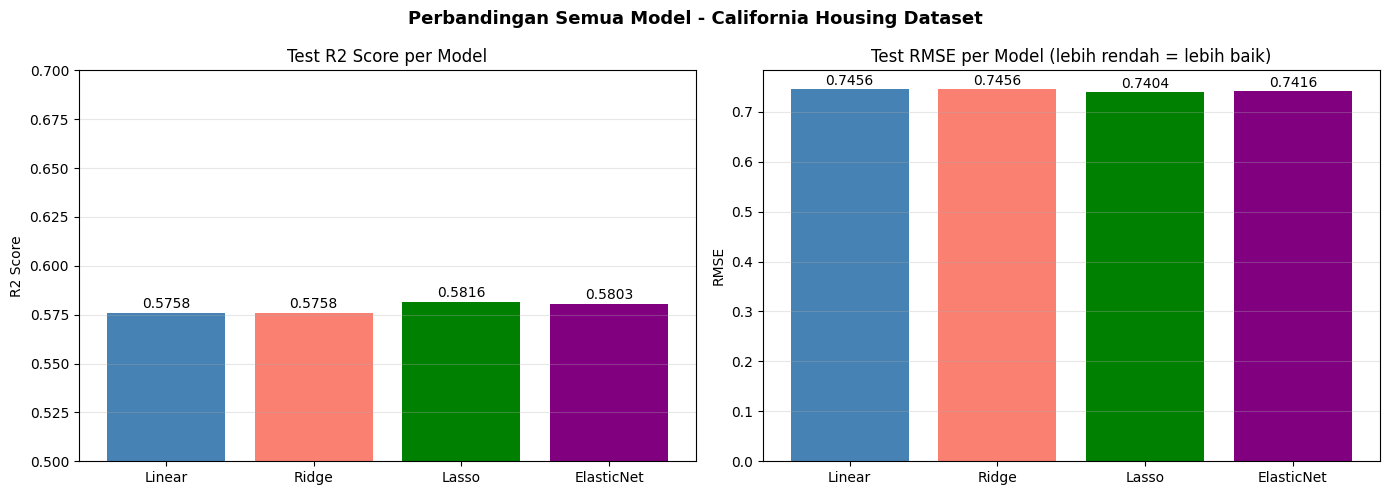

In [26]:
# Visualisasi perbandingan Test R2 dan Test RMSE
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
model_names_short = ['Linear', 'Ridge', 'Lasso', 'ElasticNet']
bar_colors = ['steelblue', 'salmon', 'green', 'purple']

# Test R2
bars1 = ax1.bar(model_names_short, summary_df['Test R2'], color=bar_colors)
for b, v in zip(bars1, summary_df['Test R2']):
    ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 0.001,
             f'{v:.4f}', ha='center', va='bottom', fontsize=10)
ax1.set_ylabel('R2 Score')
ax1.set_title('Test R2 Score per Model')
ax1.set_ylim(0.5, 0.7)
ax1.grid(True, alpha=0.3, axis='y')

# Test RMSE
bars2 = ax2.bar(model_names_short, summary_df['Test RMSE'], color=bar_colors)
for b, v in zip(bars2, summary_df['Test RMSE']):
    ax2.text(b.get_x() + b.get_width()/2, b.get_height() + 0.001,
             f'{v:.4f}', ha='center', va='bottom', fontsize=10)
ax2.set_ylabel('RMSE')
ax2.set_title('Test RMSE per Model (lebih rendah = lebih baik)')
ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle('Perbandingan Semua Model - California Housing Dataset',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Ringkasan Chapter 5

| Teknik | Kelas scikit-learn | Penalty | Efek pada Koefisien |
|--------|-------------------|---------|---------------------|
| Linear Regression | `LinearRegression()` | Tidak ada | Tidak dibatasi |
| Ridge | `Ridge(alpha=...)` | L2 (kuadrat) | Dikecilkan, tidak pernah 0 |
| Lasso | `Lasso(alpha=...)` | L1 (absolut) | Dikecilkan, bisa menjadi tepat 0 |
| ElasticNet | `ElasticNet(alpha=..., l1_ratio=...)` | L1 + L2 | Kombinasi keduanya |
| Polynomial | `PolynomialFeatures(degree=...)` + `LinearRegression()` | Tidak ada | Menangkap hubungan non-linear |
| Spline | `SplineTransformer(n_knots=...)` + `LinearRegression()` | Tidak ada | Fit piecewise polynomial halus |

### Poin Kunci untuk Diingat:

1. **Regularisasi mencegah overfitting** dengan menambahkan penalty ke fungsi loss, mendorong model untuk lebih sederhana.

2. **Ridge (L2)** mempertahankan semua fitur tapi mengecilkan koefisiennya. Pilihan yang baik ketika semua fitur mungkin relevan.

3. **Lasso (L1)** dapat membuat koefisien menjadi tepat 0, secara otomatis melakukan feature selection. Berguna untuk dataset dengan banyak fitur tidak relevan.

4. **ElasticNet** menggabungkan keduanya. Pilihan yang baik ketika terdapat multikolinearitas tinggi antar fitur.

5. **Alpha adalah hyperparameter krusial**: terlalu kecil = tidak cukup regularisasi (overfit), terlalu besar = terlalu banyak regularisasi (underfit). Gunakan `RidgeCV`, `LassoCV`, atau `GridSearchCV` untuk pemilihan otomatis.

6. **Polynomial regression** memungkinkan linear model menangkap hubungan non-linear, tapi degree terlalu tinggi menyebabkan overfitting parah.

7. **Spline interpolation** adalah alternatif yang lebih stabil untuk polynomial regression pada hubungan non-linear yang kompleks.
